## montly analysis of the measles dataset

In [1]:
# import the  libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np      
import os
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# load the data
monthly_data = pd.read_csv("../data/cases_month.csv")
monthly_data.head()


,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded
0,AFR,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0
1,AFR,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0
2,AFR,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0
3,AFR,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0
4,AFR,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0


In [4]:
monthly_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 22780 entries, 0 to 22779
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   region                 22780 non-null  str    
 1   country                22780 non-null  str    
 2   iso3                   22780 non-null  str    
 3   year                   22780 non-null  int64  
 4   month                  22780 non-null  int64  
 5   measles_suspect        22632 non-null  float64
 6   measles_clinical       22632 non-null  float64
 7   measles_epi_linked     22632 non-null  float64
 8   measles_lab_confirmed  22632 non-null  float64
 9   measles_total          22632 non-null  float64
 10  rubella_clinical       7811 non-null   float64
 11  rubella_epi_linked     7811 non-null   float64
 12  rubella_lab_confirmed  7811 non-null   float64
 13  rubella_total          7811 non-null   float64
 14  discarded              22632 non-null  float64
dtypes: float64(10

| Variable | Class | Description |
|---|---|---|
| `region` | character | Region name |
| `country` | character | Country name |
| `iso3` | character | Three-letter country code |
| `year` | double | Year |
| `month` | double | Month |
| `measles_suspect` | double | Suspected measles cases: a patient with fever and maculopapular (non-vesicular) rash, or a case suspected by a health-care worker |
| `measles_clinical` | double | Clinically compatible measles cases: suspected case with fever and maculopapular rash and at least one of cough, coryza, or conjunctivitis; no adequate specimen and not epidemiologically linked to a lab-confirmed case |
| `measles_epi_linked` | double | Epidemiologically linked measles cases: suspected measles case not lab-confirmed but geographically and temporally related (rash onset 7–23 days apart) to a lab-confirmed or epidemiologically linked case |
| `measles_lab_confirmed` | double | Laboratory-confirmed measles cases: suspected measles case confirmed positive in a proficient laboratory, with vaccine-associated illness ruled out |
| `measles_total` | double | Total measles cases: sum of clinically compatible, epidemiologically linked, and laboratory-confirmed cases |
| `rubella_clinical` | double | Clinically compatible rubella cases |
| `rubella_epi_linked` | double | Epidemiologically linked rubella cases |
| `rubella_lab_confirmed` | double | Laboratory-confirmed rubella cases |
| `rubella_total` | double | Total rubella cases |
| `discarded` | double | Discarded cases: suspected cases investigated and discarded as non-measles (and non-rubella) |

## data cleaning

In [5]:
#standardize column names
monthly_data.columns = monthly_data.columns.str.lower().str.replace(" ", "_")
monthly_data.head()

,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded
0,AFR,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0
1,AFR,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0
2,AFR,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0
3,AFR,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0
4,AFR,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0


In [6]:
#check for duplictes
monthly_data.duplicated().sum()

np.int64(0)

In [13]:
# Data cleaning pipeline (monthly measles)


monthly_clean = monthly_data.copy()

# Standardize text fields
for col in ["region", "country", "iso3"]:
    monthly_clean[col] = monthly_clean[col].astype("string").str.strip()



# Coerce numeric columns to numeric dtype
numeric_cols = [
    "year",
    "month",
    "measles_suspect",
    "measles_clinical",
    "measles_epi_linked",
    "measles_lab_confirmed",
    "measles_total",
    "rubella_clinical",
    "rubella_epi_linked",
    "rubella_lab_confirmed",
    "rubella_total",
    "discarded",
]
monthly_clean[numeric_cols] = monthly_clean[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
 )

# Keep valid months only (1-12)
monthly_clean = monthly_clean[monthly_clean["month"].between(1, 12)]

# Build helper date column from year/month
monthly_clean["report_date"] = pd.to_datetime(
    monthly_clean["year"].astype("Int64").astype("string")
    + "-"
    + monthly_clean["month"].astype("Int64").astype("string").str.zfill(2)
    + "-01",
    errors="coerce",
)

monthly_clean.head()

,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded,report_date
0,AFR,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0,2012-01-01
1,AFR,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0,2012-02-01
2,AFR,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,2012-03-01
3,AFR,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0,2012-04-01
4,AFR,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0,2012-05-01


In [14]:
# Replace invalid negative surveillance counts with missing values
count_cols = [
    "measles_suspect",
    "measles_clinical",
    "measles_epi_linked",
    "measles_lab_confirmed",
    "measles_total",
    "rubella_clinical",
    "rubella_epi_linked",
    "rubella_lab_confirmed",
    "rubella_total",
    "discarded",
]

monthly_clean[count_cols] = monthly_clean[count_cols].mask(
    monthly_clean[count_cols] < 0
)

negatives_remaining = (monthly_clean[count_cols] < 0).sum().sum()
print(f"Negative values remaining in count columns: {int(negatives_remaining)}")

Negative values remaining in count columns: 0


In [15]:
# Remove duplicate records and inspect missingness
before_rows = len(monthly_clean)
monthly_clean = monthly_clean.drop_duplicates()
after_rows = len(monthly_clean)

print(f"Rows before deduplication: {before_rows}")
print(f"Rows after deduplication:  {after_rows}")
print(f"Duplicates removed:        {before_rows - after_rows}")

monthly_clean.isna().sum().sort_values(ascending=False).head(10)

Rows before deduplication: 22780
Rows after deduplication:  22780
Duplicates removed:        0


rubella_lab_confirmed    14969
rubella_total            14969
rubella_clinical         14969
rubella_epi_linked       14969
measles_clinical           162
measles_total              154
measles_epi_linked         148
measles_suspect            148
discarded                  148
measles_lab_confirmed      148
dtype: int64

In [17]:
# Save cleaned monthly data
output_path = "../data/cases_month_clean.csv"
monthly_clean.to_csv(output_path, index=False)
print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: ../data/cases_month_clean.csv


In [11]:
# Exploratory Data Analysis (EDA): setup
eda_df = monthly_clean.copy() if "monthly_clean" in globals() else monthly_data.copy()

print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]}")

eda_df.head()

Rows: 22,780
Columns: 16


,region,country,iso3,year,month,measles_suspect,measles_clinical,measles_epi_linked,measles_lab_confirmed,measles_total,rubella_clinical,rubella_epi_linked,rubella_lab_confirmed,rubella_total,discarded,report_date
0,AFRO,Algeria,DZA,2012,1,8.0,6.0,0.0,2.0,8.0,NaN,NaN,NaN,NaN,0.0,2012-01-01
1,AFRO,Algeria,DZA,2012,2,10.0,10.0,0.0,0.0,10.0,NaN,NaN,NaN,NaN,0.0,2012-02-01
2,AFRO,Algeria,DZA,2012,3,17.0,17.0,0.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,2012-03-01
3,AFRO,Algeria,DZA,2012,4,7.0,5.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,2.0,2012-04-01
4,AFRO,Algeria,DZA,2012,5,14.0,11.0,0.0,0.0,11.0,0.0,0.0,3.0,3.0,3.0,2012-05-01


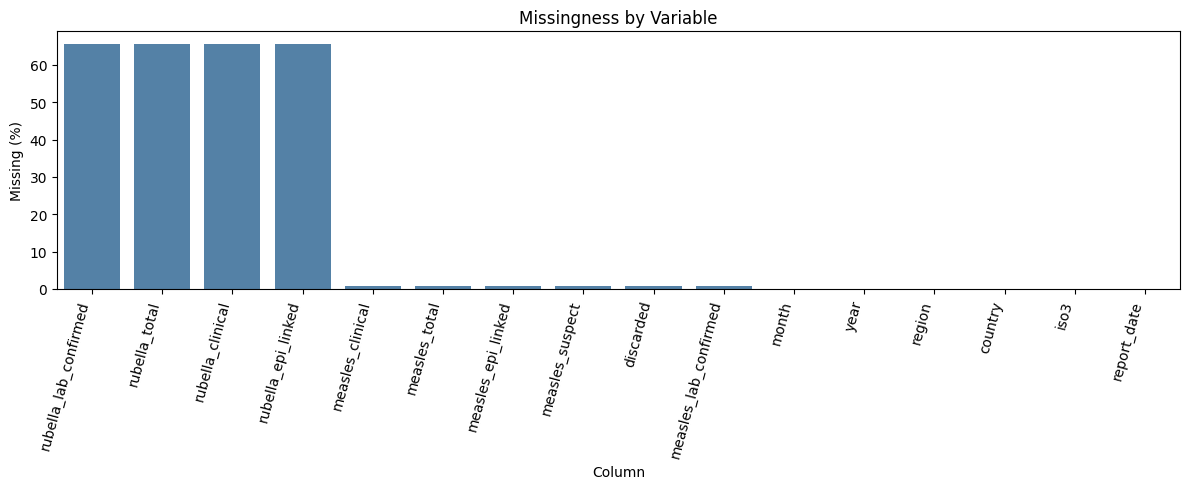

In [18]:
# Missing values by column (%)
missing_pct = (eda_df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color="steelblue")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing (%)")
plt.xlabel("Column")
plt.title("Missingness by Variable")
plt.tight_layout()
plt.show()

In [19]:
# Descriptive statistics for surveillance counts
count_cols_eda = [
    "measles_suspect", "measles_clinical", "measles_epi_linked",
    "measles_lab_confirmed", "measles_total",
    "rubella_clinical", "rubella_epi_linked",
    "rubella_lab_confirmed", "rubella_total", "discarded",
]

eda_df[count_cols_eda].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,99%,max
measles_suspect,22632.0,235.265376,1203.690535,0.0,4.0,23.0,110.0,396.0,3982.76,68051.0
measles_clinical,22618.0,50.774427,408.309716,0.0,0.0,0.0,2.0,21.0,1218.81,12730.0
measles_epi_linked,22632.0,38.939069,748.287331,0.0,0.0,0.0,0.0,13.9,671.07,67728.0
measles_lab_confirmed,22632.0,47.029251,275.099951,0.0,0.0,1.0,14.0,78.0,748.69,9936.0
measles_total,22626.0,136.724255,969.350014,0.0,0.0,2.0,29.0,184.0,2621.00,67929.0
rubella_clinical,7811.0,19.815901,283.628969,0.0,0.0,0.0,0.0,1.0,310.20,10856.0
rubella_epi_linked,7811.0,4.344130,60.004873,0.0,0.0,0.0,0.0,0.0,66.80,2476.0
rubella_lab_confirmed,7811.0,20.066317,145.382545,0.0,1.0,3.0,11.0,37.0,226.80,7039.0
rubella_total,7811.0,44.226347,335.242009,0.0,1.0,4.0,15.0,55.0,689.70,10856.0
discarded,22632.0,112.301653,524.224152,0.0,1.0,14.0,60.0,202.0,1880.00,16443.0


In [20]:
# Dataset overview and data quality snapshot
eda_df.info()

summary_table = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "n_unique": eda_df.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

summary_table

<class 'pandas.DataFrame'>
RangeIndex: 22780 entries, 0 to 22779
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   region                 22780 non-null  string        
 1   country                22780 non-null  string        
 2   iso3                   22780 non-null  string        
 3   year                   22780 non-null  int64         
 4   month                  22780 non-null  int64         
 5   measles_suspect        22632 non-null  float64       
 6   measles_clinical       22618 non-null  float64       
 7   measles_epi_linked     22632 non-null  float64       
 8   measles_lab_confirmed  22632 non-null  float64       
 9   measles_total          22626 non-null  float64       
 10  rubella_clinical       7811 non-null   float64       
 11  rubella_epi_linked     7811 non-null   float64       
 12  rubella_lab_confirmed  7811 non-null   float64       
 13  rubella_tota

,dtype,missing_count,missing_pct,n_unique
rubella_lab_confirmed,float64,14969,65.71,271
rubella_total,float64,14969,65.71,399
rubella_clinical,float64,14969,65.71,207
rubella_epi_linked,float64,14969,65.71,125
measles_clinical,float64,162,0.71,800
measles_total,float64,154,0.68,1372
measles_epi_linked,float64,148,0.65,669
measles_suspect,float64,148,0.65,1723
discarded,float64,148,0.65,1120
measles_lab_confirmed,float64,148,0.65,784


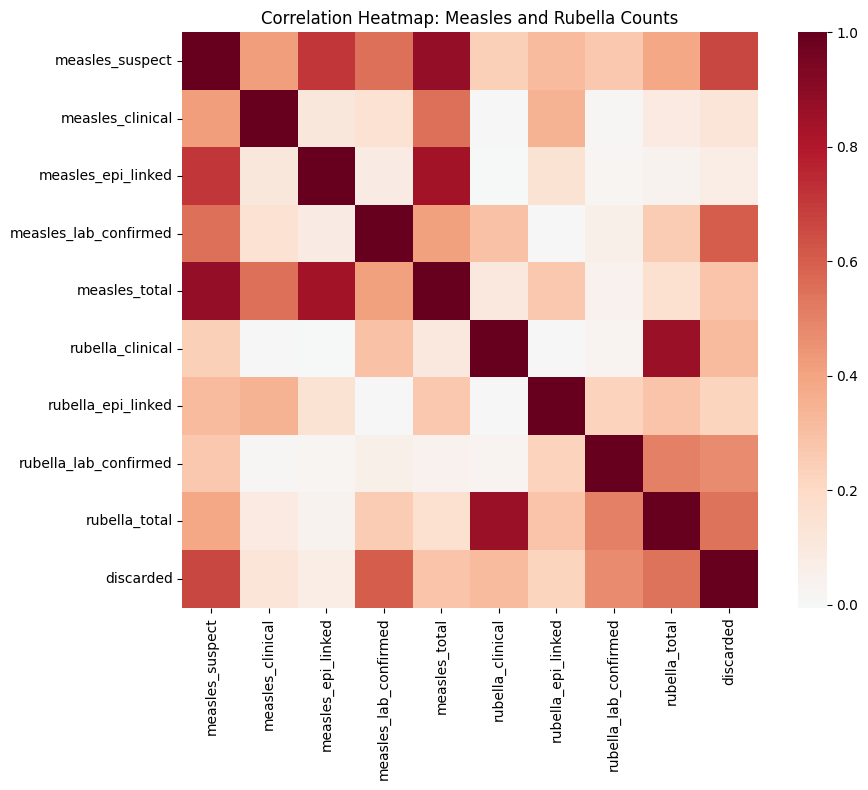

In [21]:
# Correlation between surveillance count variables
corr_matrix = eda_df[count_cols_eda].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=False, square=True)
plt.title("Correlation Heatmap: Measles and Rubella Counts")
plt.tight_layout()
plt.show()

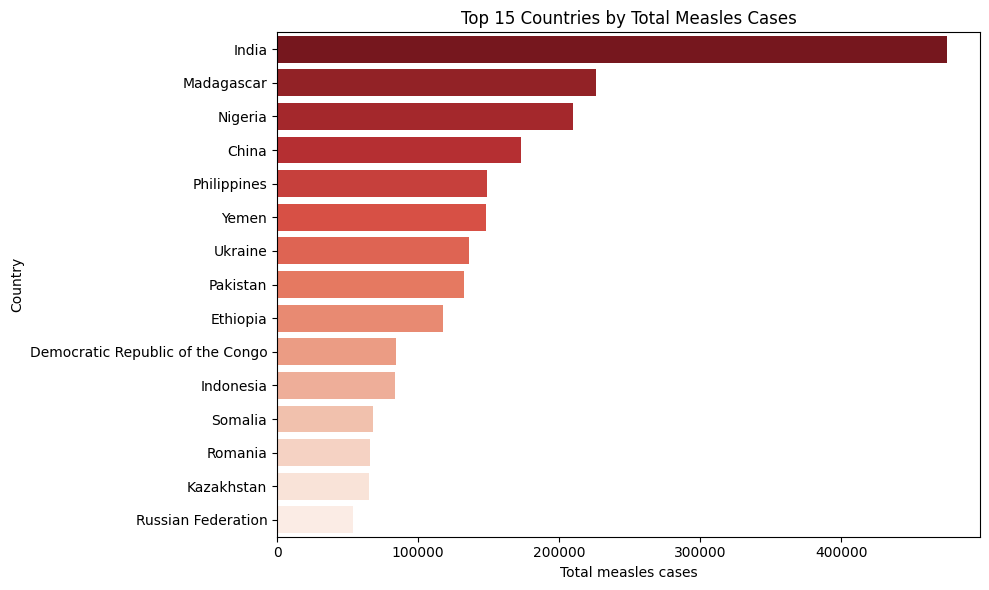

In [25]:
# Top 15 countries by total measles burden
top_countries = (
    eda_df.groupby("country", as_index=False)["measles_total"]
    .sum(min_count=1)
    .sort_values("measles_total", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, y="country", x="measles_total", palette="Reds_r")
plt.title("Top 15 Countries by Total Measles Cases")
plt.xlabel("Total measles cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

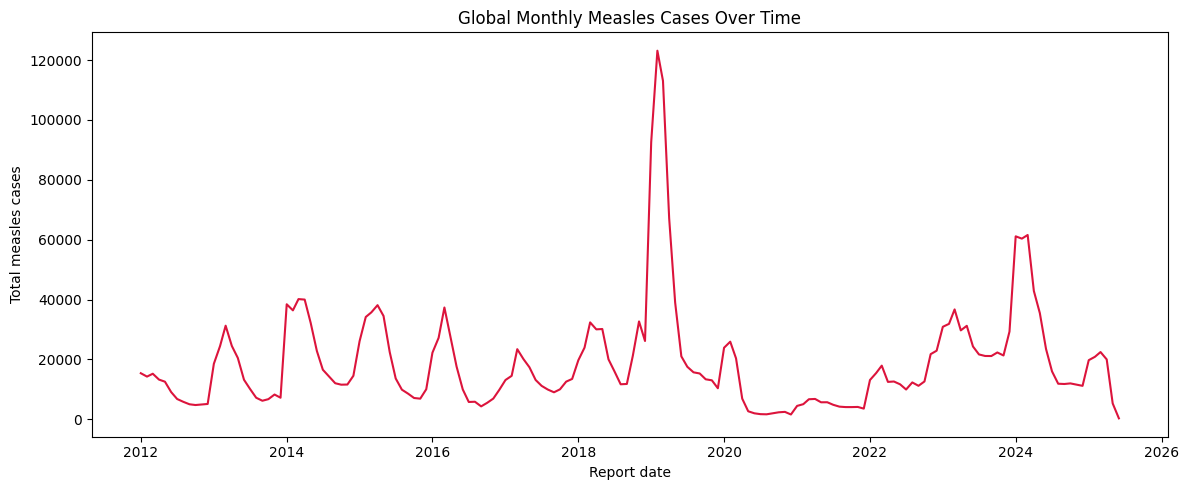

In [22]:
# Monthly global measles trend
trend_df = (
    eda_df.groupby("report_date", as_index=False)["measles_total"]
    .sum(min_count=1)
    .sort_values("report_date")
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x="report_date", y="measles_total", color="crimson")
plt.title("Global Monthly Measles Cases Over Time")
plt.xlabel("Report date")
plt.ylabel("Total measles cases")
plt.tight_layout()
plt.show()

In [24]:
# Measles variation within months across years (seasonality heatmap) - Plotly
month_year = eda_df.copy()
month_year["year"] = pd.to_numeric(month_year["year"], errors="coerce")
month_year["month"] = pd.to_numeric(month_year["month"], errors="coerce")

heatmap_df = (
    month_year.groupby(["year", "month"], as_index=False)["measles_total"]
    .sum(min_count=1)
    .dropna(subset=["year", "month"])
)

heatmap_pivot = heatmap_df.pivot(index="year", columns="month", values="measles_total")
heatmap_pivot = heatmap_pivot.reindex(columns=range(1, 13))

month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
heatmap_pivot.columns = [month_labels[m] for m in heatmap_pivot.columns]

fig = px.imshow(
    heatmap_pivot,
    color_continuous_scale="YlOrRd",
    labels={"x": "Month", "y": "Year", "color": "Total measles cases"},
    aspect="auto",
)

fig.update_layout(title="Measles Cases by Month Across Years")
fig.update_xaxes(side="bottom")
fig.show()
